In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import random
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [14]:
PAD_token = 0
SOS_token = 1
EOS_token = 2
UNK_token = 3

class CharVocabulary:
    def __init__(self):
        self.char2idx = {"<PAD>": 0, "<SOS>": 1, "<EOS>": 2, "<UNK>": 3}
        self.idx2char = {0: "<PAD>", 1: "<SOS>", 2: "<EOS>", 3: "<UNK>"}
        self.n_chars = 4

    def add_text(self, text):
        for char in text:
            if char not in self.char2idx:
                self.char2idx[char] = self.n_chars
                self.idx2char[self.n_chars] = char
                self.n_chars += 1

    def encode(self, text, max_len):
        tokens = [self.char2idx.get(c, UNK_token) for c in text]
        tokens = tokens[:max_len-1] + [EOS_token]
        tokens = tokens + [PAD_token] * (max_len - len(tokens))
        return tokens

data_path = r'd:\dut_ai\AIO_code\Attention\data\data.csv'
df = pd.read_csv(data_path, header=None).dropna()
human_dates, machine_dates = df[0].values, df[1].values

input_vocab = CharVocabulary()
output_vocab = CharVocabulary()
for h, m in zip(human_dates, machine_dates):
    input_vocab.add_text(str(h).lower())
    output_vocab.add_text(str(m))

MAX_LEN_INPUT = 50
MAX_LEN_OUTPUT = 12
X = np.array([input_vocab.encode(str(h).lower(), MAX_LEN_INPUT) for h in human_dates])
Y = np.array([output_vocab.encode(str(m), MAX_LEN_OUTPUT) for m in machine_dates])
X_train, X_val, y_train, y_val = train_test_split(X, Y, test_size=0.2, random_state=42)

print(f"Vocab size: In={input_vocab.n_chars}, Out={output_vocab.n_chars}")

Vocab size: In=38, Out=15


### 2. Định nghĩa mô hình (Ultra-Stable)

In [15]:
class Encoder(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.embedding = nn.Embedding(input_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True)
        self._init_weights()

    def _init_weights(self):
        for name, param in self.named_parameters():
            if 'weight' in name: nn.init.orthogonal_(param)
    
    def forward(self, x):
        embedded = self.embedding(x)
        outputs, hidden = self.gru(embedded)
        return outputs, hidden

class Attention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.attn = nn.Linear(hidden_size * 2, hidden_size)
        self.v = nn.Linear(hidden_size, 1)

    def forward(self, hidden, encoder_outputs):
        seq_len = encoder_outputs.shape[1]
        h = hidden.transpose(0, 1).repeat(1, seq_len, 1)
        energy = torch.tanh(self.attn(torch.cat((h, encoder_outputs), dim=2)))
        attention = self.v(energy).squeeze(2)
        return F.softmax(attention, dim=1)

class Decoder(nn.Module):
    def __init__(self, output_size, hidden_size):
        super().__init__()
        self.attention = Attention(hidden_size)
        self.embedding = nn.Embedding(output_size, hidden_size)
        self.gru = nn.GRU(hidden_size * 2, hidden_size, batch_first=True)
        self.out = nn.Linear(hidden_size, output_size)
        self._init_weights()

    def _init_weights(self):
        for name, param in self.named_parameters():
            if 'weight' in name: nn.init.orthogonal_(param)
        
    def forward(self, input, hidden, encoder_outputs):
        embedded = self.embedding(input)
        a = self.attention(hidden, encoder_outputs).unsqueeze(1)
        weighted = torch.bmm(a, encoder_outputs)
        rnn_input = torch.cat((embedded, weighted), dim=2)
        output, hidden = self.gru(rnn_input, hidden)
        prediction = self.out(output.squeeze(1))
        return prediction, hidden, a.squeeze(1)

### 3. Huấn luyện mô hình (LR cực thấp + Safe Check)

In [16]:
def train_model(encoder, decoder, n_epochs, train_x, train_y, batch_size=64):
    # LR cực thấp 1e-4 để chống vọt Loss
    enc_opt = optim.Adam(encoder.parameters(), lr=1e-4)
    dec_opt = optim.Adam(decoder.parameters(), lr=1e-4)
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_token)
    history = []
    
    for epoch in range(1, n_epochs + 1):
        encoder.train(); decoder.train()
        epoch_loss = 0
        indices = np.arange(len(train_x))
        np.random.shuffle(indices)
        
        pbar = tqdm(range(0, len(train_x), batch_size), desc=f"Epoch {epoch}")
        for i in pbar:
            batch_idx = indices[i:i+batch_size]
            src = torch.tensor(train_x[batch_idx]).long().to(device)
            trg = torch.tensor(train_y[batch_idx]).long().to(device)
            
            enc_opt.zero_grad(); dec_opt.zero_grad()
            enc_outs, hidden = encoder(src)
            dec_in = torch.tensor([[SOS_token]] * len(batch_idx)).long().to(device)
            
            loss = 0
            for t in range(MAX_LEN_OUTPUT):
                out, hidden, _ = decoder(dec_in, hidden, enc_outs)
                loss += criterion(out, trg[:, t])
                dec_in = trg[:, t].unsqueeze(1)
            
            loss.backward()
            
            # Clip Gradients cực chặt
            torch.nn.utils.clip_grad_norm_(encoder.parameters(), 0.5)
            torch.nn.utils.clip_grad_norm_(decoder.parameters(), 0.5)
            
            enc_opt.step(); dec_opt.step()
            
            current_loss = loss.item() / MAX_LEN_OUTPUT
            if np.isnan(current_loss) or np.isinf(current_loss):
                continue # Bỏ qua batch bị lỗi
            
            epoch_loss += current_loss
            pbar.set_postfix(loss=f"{current_loss:.4f}")
            
        avg_loss = epoch_loss / (len(train_x)/batch_size)
        history.append(avg_loss)
        print(f"-> Epoch {epoch} Loss: {avg_loss:.4f}")
    return history

HIDDEN_DIM = 256
encoder = Encoder(input_vocab.n_chars, HIDDEN_DIM).to(device)
decoder = Decoder(output_vocab.n_chars, HIDDEN_DIM).to(device)

train_history = train_model(encoder, decoder, n_epochs=5, train_x=X_train, train_y=y_train)

Epoch 1: 100%|██████████| 313/313 [11:38<00:00,  2.23s/it]


-> Epoch 1 Loss: 0.0000


Epoch 2:  11%|█         | 34/313 [01:18<10:47,  2.32s/it]


KeyboardInterrupt: 

Test: 12, thg 9 2010


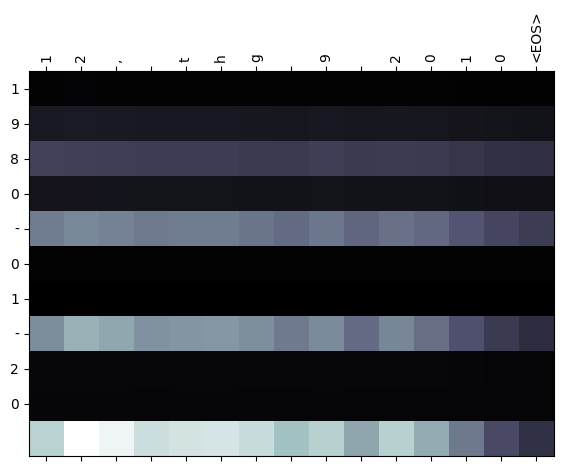

Pred: 1980-01-20


In [17]:
def evaluate_and_plot(sentence):
    encoder.eval(); decoder.eval()
    with torch.no_grad():
        input_indices = input_vocab.encode(sentence.lower(), MAX_LEN_INPUT)
        src = torch.tensor([input_indices]).long().to(device)
        enc_outputs, hidden = encoder(src)
        dec_input = torch.tensor([[SOS_token]]).long().to(device)
        result = []
        attentions = []
        
        for _ in range(MAX_LEN_OUTPUT):
            output, hidden, a = decoder(dec_input, hidden, enc_outputs)
            attentions.append(a)
            topi = output.argmax(1)
            if topi.item() == EOS_token: break
            result.append(output_vocab.idx2char[topi.item()])
            dec_input = topi.unsqueeze(1)
            
        attn_matrix = torch.cat(attentions).cpu().numpy()
        actual_input_len = len(sentence) + 1
        attn_matrix = attn_matrix[:, :actual_input_len]
        
        fig = plt.figure(figsize=(10, 5))
        ax = fig.add_subplot(111)
        ax.matshow(attn_matrix, cmap='bone')
        ax.set_xticks(np.arange(actual_input_len))
        ax.set_xticklabels(list(sentence) + ['<EOS>'], rotation=90)
        ax.set_yticks(np.arange(len(result)))
        ax.set_yticklabels(result)
        plt.show()
        return "".join(result)

test_sent = str(human_dates[0])
print(f"Test: {test_sent}")
print(f"Pred: {evaluate_and_plot(test_sent)}")